In [ ]:
from models.dust3r.utils.positional_embeddings import TimePositionEmbedding

print(time_position_embedding)

tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000])
tensor([1.0000e+00, 5.6569e+00, 3.2000e+01, 1.8102e+02, 1.0240e+03])
TimePositionEmbedding()


In [5]:
import torch

time_position_embedding = TimePositionEmbedding(10, 10)
time_position_embedding(torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000])
tensor([1.0000e+00, 5.6569e+00, 3.2000e+01, 1.8102e+02, 1.0240e+03])


tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  1.0000,  1.0000,
          1.0000,  1.0000],
        [ 0.8415, -0.5862,  0.5514, -0.9295, -0.1585,  0.5403,  0.8102,  0.8342,
          0.3688,  0.9874],
        [ 0.9093, -0.9498,  0.9200, -0.6857, -0.3131, -0.4161,  0.3128,  0.3919,
         -0.7279,  0.9497],
        [ 0.1411, -0.9529,  0.9836,  0.4237, -0.4597, -0.9900, -0.3033, -0.1804,
         -0.9058,  0.8881],
        [-0.7568, -0.5942,  0.7210,  0.9982, -0.5946, -0.6536, -0.8043, -0.6929,
          0.0597,  0.8040],
        [-0.9589, -0.0099,  0.2194,  0.3127, -0.7146,  0.2837, -1.0000, -0.9756,
          0.9499,  0.6996],
        [-0.2794,  0.5781, -0.3549, -0.7676, -0.8164,  0.9602, -0.8160, -0.9349,
          0.6409,  0.5774],
        [ 0.6570,  0.9467, -0.8116, -0.8789, -0.8977,  0.7539, -0.3222, -0.5842,
         -0.4770,  0.4407],
        [ 0.9894,  0.9558, -0.9992,  0.1193, -0.9562, -0.1455,  0.2939, -0.0398,
         -0.9929,  0.2928],
        [ 0.4121,  

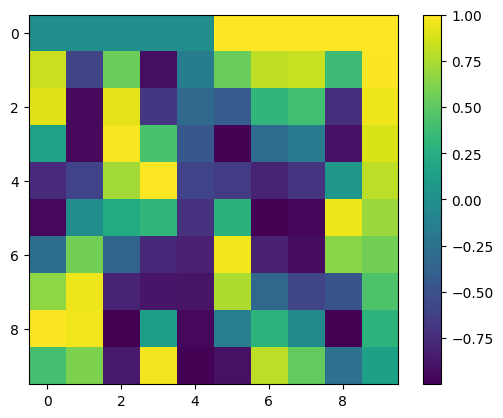

In [4]:
import matplotlib.pyplot as plt

plt.imshow(time_position_embedding(torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])).detach().numpy())
plt.colorbar()
plt.show()

In [9]:
import math
import torch
from torch import nn

class TimePosEmbedding(nn.Module):
    def __init__(self, emb_dim=128, out_dim=256):
        super().__init__()
        self.emb_dim = emb_dim
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim)
        )
    def forward(self, t): # t: (B,) scalar times
        b = t.shape[0]
        half = self.emb_dim // 2
        i = torch.arange(half, device=t.device, dtype=t.dtype)
        print(i)
        e = t.view(b,1) * (10000**(-i/(half-1)))
        e = torch.cat([e.sin(), e.cos()], -1) # (B, emb_dim)
        return self.mlp(e) # (B, out_dim)

In [10]:
time_pos_embed = TimePosEmbedding(10, 10)
out = time_pos_embed(torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))
out

tensor([0, 1, 2, 3, 4])


tensor([[ 0.1182,  0.2178,  0.2053, -0.0127, -0.0960, -0.3690,  0.1152,  0.3695,
         -0.0716, -0.3241],
        [ 0.0574,  0.2117,  0.2326,  0.0185, -0.0474, -0.4076,  0.1545,  0.3450,
         -0.0704, -0.3690],
        [ 0.0265,  0.2388,  0.2699,  0.0418,  0.0516, -0.3796,  0.1593,  0.3394,
         -0.1191, -0.3212],
        [ 0.0442,  0.2795,  0.2747,  0.0371,  0.0897, -0.2941,  0.1393,  0.3522,
         -0.1369, -0.2555],
        [ 0.0996,  0.3069,  0.2363,  0.0184,  0.0292, -0.2205,  0.1162,  0.3744,
         -0.0964, -0.2253],
        [ 0.1447,  0.2833,  0.1979, -0.0063, -0.0577, -0.2343,  0.1122,  0.3987,
         -0.0637, -0.2444],
        [ 0.1308,  0.2297,  0.1881, -0.0162, -0.1122, -0.3107,  0.1475,  0.3988,
         -0.0368, -0.3240],
        [ 0.0743,  0.2057,  0.2085,  0.0063, -0.0966, -0.3662,  0.1964,  0.3722,
         -0.0176, -0.3924],
        [ 0.0341,  0.2207,  0.2484,  0.0328, -0.0049, -0.3609,  0.2099,  0.3562,
         -0.0574, -0.3645],
        [ 0.0399,  

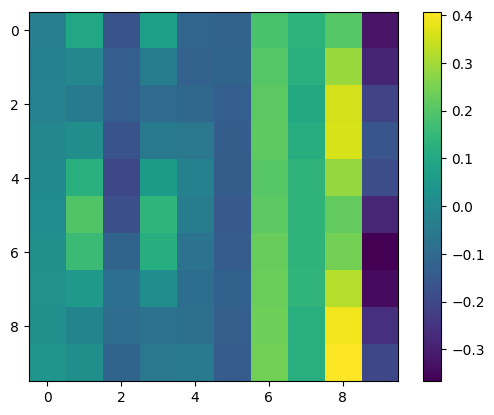

In [8]:
import matplotlib.pyplot as plt

plt.imshow(out.detach().numpy())
plt.colorbar()
plt.show()